In [1]:
import torch

torch.__version__

'2.10.0+cu128'

In [3]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l


In [4]:
def synthetic_data(w, b, num_examples):
    "生成 y = Xw + b + 噪声."
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, torch.reshape(y, (-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [5]:
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([-0.5701,  1.9037]) 
label: tensor([-3.4132])


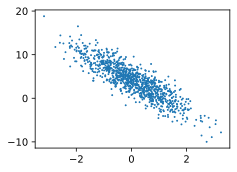

In [6]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), 
                labels.detach().numpy(), 1)

In [9]:
def data_iter(batch_size, features, labels):
    num_examples = len(features) #features.shape[0]
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])  # [i:i+batch_size]这一操作实现了取 batch_size个数据
        yield features[batch_indices], labels[batch_indices]

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.1194, -1.3421],
        [ 0.1036,  0.9395],
        [ 1.9074, -0.6741],
        [-2.7204,  0.9788],
        [-0.1231, -0.8401],
        [-1.9378,  0.1063],
        [ 0.4341,  1.1452],
        [ 1.4882,  0.8240],
        [-0.8278, -1.2087],
        [ 0.6555,  1.4059]]) 
 tensor([[ 9.0060],
        [ 1.2192],
        [10.3016],
        [-4.5514],
        [ 6.7996],
        [-0.0327],
        [ 1.1870],
        [ 4.3761],
        [ 6.6610],
        [ 0.7414]])


In [10]:
# 定义初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [11]:
# 定义模型
def linreg(X, w, b):
    "线性回归模型"
    return torch.matmul(X, w) + b

In [12]:
def squared_loss(y_hat, y):
    "平方损失函数"
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
# 保证作差运算时，两个向量长度一致

In [13]:
def sgd(params, lr, batch_size):
    "小批量随机梯度下降"
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()


In [14]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.043803
epoch 2, loss 0.000165
epoch 3, loss 0.000048


In [15]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0002, -0.0008], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0007], grad_fn=<RsubBackward1>)


In [16]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [18]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))

[tensor([[-0.4163,  0.7680],
         [-0.1780,  1.5934],
         [ 0.1521,  1.9716],
         [ 0.8936, -0.5075],
         [-1.7018, -2.2457],
         [ 1.6399, -1.2193],
         [ 2.2326,  0.7801],
         [ 0.2701,  0.1833],
         [-0.9779, -0.5030],
         [ 0.8062,  0.3999]]),
 tensor([[ 0.7499],
         [-1.5700],
         [-2.1814],
         [ 7.7167],
         [ 8.4467],
         [11.6253],
         [ 6.0192],
         [ 4.1330],
         [ 3.9574],
         [ 4.4570]])]

In [19]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [20]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [21]:
loss = nn.MSELoss()

In [22]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [23]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000265
epoch 2, loss 0.000104
epoch 3, loss 0.000103
